# Assignment 3: Milestone I Natural Language Processing
## Task 2. Generating Feature Representations
#### Student Name: Le Quang Thao
#### Student ID: s4028673


Environment: Python 3 and Jupyter notebook

Libraries used:
* pandas
* numpy
* scikit-learn
* gensim
* matplotlib
* collections
* os
* shutil

## Introduction
This notebook implements **Task 2** of the NLP pipeline for the cosmetics and beauty products reviews dataset. The goal of this task is to convert each processed review into feature representations that can later be used in Task 3 for classification experiments.

In this task, I only use the processed review text stored in `processed_review`. The `review_title` column is not used, which matches the assignment requirement for Task 2.

The three required outputs are:
1. `count_vectors.txt` using the Task 1 vocabulary.
2. `unweighted_vectors.txt` using unweighted Word2Vec document vectors.
3. `weighted_vectors.txt` using TF-IDF weighted Word2Vec document vectors.

## Task 2. Generating Feature Representations

## Importing libraries

These libraries are used for reading the Task 1 outputs, building sparse and dense vector representations, running small validation checks, and saving the required files.


In [1]:
# Import libraries for data loading, vector generation, plotting, and file writing
import pandas as pd
import numpy as np
import shutil
import os
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

Word2Vec is used as the embedding language model for the dense document representations.  
If this import fails, install `gensim` first and restart the kernel before running the notebook again.


In [3]:
from gensim.models import Word2Vec

## 1. Examining and loading data

I briefly inspect the original dataset first so the notebook records the source columns and confirms that the review information is available. The actual feature generation below uses `processed.csv`, not the raw `review_text`.


In [4]:
# I load the original review dataset only for a quick structural check.
raw_data = pd.read_csv('cosmetics_beauty_products_reviews.csv')

print('Raw data shape:', raw_data.shape)
print('Raw data columns:')
print(raw_data.columns.tolist())

Raw data shape: (61284, 15)
Raw data columns:
['product_id', 'brand_name', 'review_id', 'review_title', 'review_text', 'author', 'review_date', 'review_rating', 'is_a_buyer', 'product_title', 'price', 'avg_product_rating', 'product_rating_count', 'product_tags', 'product_url']


In [5]:
# Preview the key columns related to Task 2 and Task 3.
raw_data[['review_id', 'review_title', 'review_text', 'is_a_buyer']].head(3)

,review_id,review_title,review_text,is_a_buyer
0,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,True
1,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,True
2,15618995,perfect for summers dry for winters,I have been using this product for months now....,True


In [6]:
print('Missing review_text values:', raw_data['review_text'].isna().sum())
print('Buyer label counts:')
print(raw_data['is_a_buyer'].value_counts())

Missing review_text values: 9
Buyer label counts:
is_a_buyer
True     48222
False    13062
Name: count, dtype: int64


## 2. Loading the processed reviews

The main column required here is `processed_review`, which already stores the cleaned review text as a whitespace-separated string of tokens.


In [7]:
# `processed.csv` is the direct output of Task 1 and contains the cleaned text
# that should be transformed into document vectors in this task.
reviews = pd.read_csv('processed.csv')

print('Processed data shape:', reviews.shape)
print('Processed data columns:')
print(reviews.columns.tolist())

Processed data shape: (61284, 9)
Processed data columns:
['review_id', 'review_title', 'review_text', 'is_a_buyer', 'brand_name', 'product_title', 'avg_product_rating', 'price', 'processed_review']


In [8]:
reviews.head(3)

,review_id,review_title,review_text,is_a_buyer,brand_name,product_title,avg_product_rating,price,processed_review
0,16752142,Worth buying 50g one,Works as it claims. Could see the difference f...,True,Olay,Olay Ultra Lightweight Moisturiser: Luminous W...,4.1,1599,works claims difference day olay cleanser results
1,14682550,Best cream to start ur day,It does what it claims . Best thing is it smoo...,True,Olay,Olay Ultra Lightweight Moisturiser: Luminous W...,4.1,1599,claims thing smoothens ur makes soft
2,15618995,perfect for summers dry for winters,I have been using this product for months now....,True,Olay,Olay Ultra Lightweight Moisturiser: Luminous W...,4.1,1599,months combination oily greasy absorbs quickly...


Some reviews become empty after Task 1 removes short words, stop words, rare words, and the most common words. I keep those reviews in the dataset and convert missing values to empty strings so every original review still gets exactly one output line in each Task 2 file.


In [9]:
# Missing processed reviews are changed to empty strings so each original review
# still receives one output row in all Task 2 files.
reviews['processed_review'] = reviews['processed_review'].fillna('')

review_txts = reviews['processed_review'].astype(str).tolist()

print('Number of processed reviews:', len(review_txts))
print('First processed review:')
print(review_txts[0])

Number of processed reviews: 61284
First processed review:
works claims difference day olay cleanser results


### 2.1 Reconstructing token lists

The processed reviews are already cleaned and stored in a whitespace-separated form, so a simple split is enough to reconstruct the token list for each review. No extra regex tokenization is needed at this stage.


In [10]:
tokenised_reviews = []

for review in review_txts:
    tokenised_reviews.append(review.split())

print('First tokenised review:')
print(tokenised_reviews[0])

First tokenised review:
['works', 'claims', 'difference', 'day', 'olay', 'cleanser', 'results']


In [11]:
# Review lengths provide a quick sense of sparsity and show whether some
# documents became empty after Task 1 filtering.
review_lengths = []

for tokens in tokenised_reviews:
    review_lengths.append(len(tokens))

print('Shortest review length:', min(review_lengths))
print('Longest review length:', max(review_lengths))
print('Average review length:', np.mean(review_lengths))

Shortest review length: 0
Longest review length: 133
Average review length: 7.082305332550095


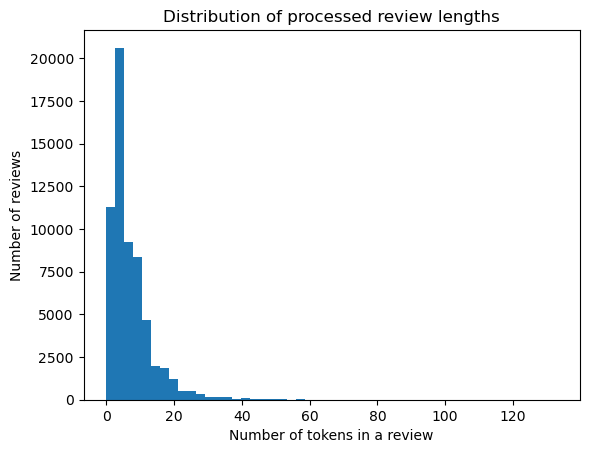

In [12]:
plt.hist(review_lengths, bins=50)
plt.xlabel('Number of tokens in a review')
plt.ylabel('Number of reviews')
plt.title('Distribution of processed review lengths')
plt.show()

## 3. Loading the Task 1 vocabulary

The assignment requires the count vectors to use the exact vocabulary created in Task 1. Therefore, I load `vocab.txt` and reconstruct the `word:index` mapping so it can be passed directly to the vectorizers.


In [13]:
vocab = {}

with open('vocab.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line != '':
            word, index = line.rsplit(':', 1)
            vocab[word] = int(index)

print('Vocabulary size:', len(vocab))

Vocabulary size: 8054


In [14]:
# I also build a vocabulary list sorted by index so the dense embedding matrix
# stays aligned with the same vocabulary order used by the sparse vectors.
vocab_words = []

for word, index in sorted(vocab.items(), key=lambda x: x[1]):
    vocab_words.append(word)

print('First 10 vocabulary words:')
print(vocab_words[:10])
print('Last 10 vocabulary words:')
print(vocab_words[-10:])

First 10 vocabulary words:
['aa', 'aback', 'abd', 'abh', 'ability', 'abit', 'abnormally', 'abroad', 'abs', 'absent']
Last 10 vocabulary words:
['yummy', 'yur', 'zed', 'zet', 'zip', 'zipper', 'zips', 'zit', 'zits', 'zone']


## 4. Generating count vectors

Each row corresponds to one review and each column corresponds to one word in the Task 1 vocabulary.


In [15]:
# I reuse the Task 1 vocabulary exactly as given. Lowercasing is disabled
# because Task 1 already normalised the text, and the tokenizer simply splits
# on whitespace so scikit-learn does not process the cleaned strings differently.
cVectorizer = CountVectorizer(
    analyzer='word',
    vocabulary=vocab,
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

count_features = cVectorizer.fit_transform(review_txts)

print('Count vector shape:', count_features.shape)
print('Number of non-zero count values:', count_features.nnz)

Count vector shape: (61284, 8054)
Number of non-zero count values: 412185


In [16]:
print('Number of reviews:', len(review_txts))
print('Vocabulary size:', len(vocab))
print('Count matrix rows:', count_features.shape[0])
print('Count matrix columns:', count_features.shape[1])

Number of reviews: 61284
Vocabulary size: 8054
Count matrix rows: 61284
Count matrix columns: 8054


### 4.1 Checking one count vector

Following the validation habit shown in Act 3, I manually inspect one example review and compare its tokens with the sparse `word_index:frequency` representation.


In [17]:
test_ind = 0

print('Review index:', test_ind)
print('Processed review:')
print(review_txts[test_ind])
print('Tokens:')
print(tokenised_reviews[test_ind])

for word_index in count_features[test_ind].nonzero()[1]:
    value = count_features[test_ind][0, word_index]
    print(str(word_index) + ':' + str(value), end=',')

Review index: 0
Processed review:
works claims difference day olay cleanser results
Tokens:
['works', 'claims', 'difference', 'day', 'olay', 'cleanser', 'results']
1140:1,1160:1,1706:1,1873:1,4828:1,5879:1,7940:1,

In [18]:
# `Counter` gives a second quick check that the token counts match the sparse
# count-vector entries printed above.
Counter(tokenised_reviews[test_ind])

Counter({'works': 1,
         'claims': 1,
         'difference': 1,
         'day': 1,
         'olay': 1,
         'cleanser': 1,
         'results': 1})

## 5. Generating TF-IDF weights

TF-IDF is needed for the weighted embedding representation. I use the same Task 1 vocabulary so that the weighted and unweighted document vectors are based on the same feature space.


In [19]:
tVectorizer = TfidfVectorizer(
    analyzer='word',
    vocabulary=vocab,
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False
)

tfidf_features = tVectorizer.fit_transform(review_txts)

print('TF-IDF vector shape:', tfidf_features.shape)
print('Number of non-zero TF-IDF values:', tfidf_features.nnz)

TF-IDF vector shape: (61284, 8054)
Number of non-zero TF-IDF values: 412185


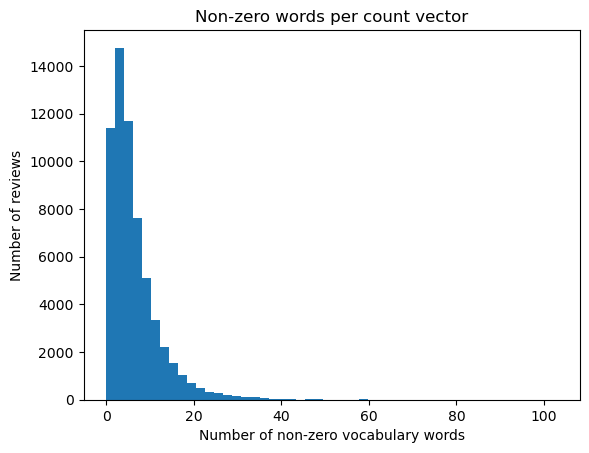

In [20]:
non_zero_counts = count_features.getnnz(axis=1)

# Optional diagnostic plot. Uncomment these lines if you want to display it.
plt.hist(non_zero_counts, bins=50)
plt.xlabel('Number of non-zero vocabulary words')
plt.ylabel('Number of reviews')
plt.title('Non-zero words per count vector')
plt.show()

## 6. Training the embedding model

The assignment allows the use of an embedding language model. Here I train a Word2Vec model directly on the processed cosmetics review corpus so the word vectors reflect the vocabulary and context of this dataset.

I use a 50-dimensional embedding because it is compact, easy to inspect, and still provides a dense document representation.


In [21]:
embedding_size = 50

w2v_model = Word2Vec(
    sentences=tokenised_reviews,
    vector_size=embedding_size,
    window=5,
    min_count=1,
    workers=1,
    sg=0,
    seed=42,
    epochs=5
)

print('Word2Vec vocabulary size:', len(w2v_model.wv))
print('Word2Vec vector size:', w2v_model.vector_size)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec vocabulary size: 8054
Word2Vec vector size: 50


In [22]:
example_word = vocab_words[0]

print('Example word:', example_word)
print('First 5 vector values:')
print(w2v_model.wv[example_word][:5])

Example word: aa
First 5 vector values:
[-0.01579433 -0.04771915  0.01701754  0.01937068  0.00481751]


### 6.1 Preparing the embedding matrix

To make document-vector construction efficient, I place one word embedding in each row of a matrix whose order matches the Task 1 vocabulary index. 


In [23]:
embedding_matrix = np.zeros((len(vocab_words), embedding_size))

for index, word in enumerate(vocab_words):
    if word in w2v_model.wv:
        embedding_matrix[index] = w2v_model.wv[word]

print('Embedding matrix shape:', embedding_matrix.shape)

Embedding matrix shape: (8054, 50)


## 7. Generating unweighted document vectors

The unweighted document vector is the average of the Word2Vec embeddings of all words that appear in the review.


In [24]:
# `count_features.dot(embedding_matrix)` gives the sum of each review's word
# vectors weighted by raw counts. Dividing by the token count turns this sum
# into the average embedding of the review.
row_sums = np.asarray(count_features.sum(axis=1)).ravel()

unweighted_vectors = count_features.dot(embedding_matrix)

non_empty_rows = row_sums > 0
unweighted_vectors[non_empty_rows] = unweighted_vectors[non_empty_rows] / row_sums[non_empty_rows, None]

print('Unweighted vector shape:', unweighted_vectors.shape)
print('First 5 values of first review vector:')
print(unweighted_vectors[0][:5])

Unweighted vector shape: (61284, 50)
First 5 values of first review vector:
[-0.21553796 -0.49396439 -0.88566513  0.04292659  0.15148608]


## 8. Generating TF-IDF weighted document vectors

The weighted document vector uses TF-IDF values instead of raw counts so that more distinctive words contribute more strongly to the final embedding of a review.


In [25]:
# This is the weighted version of the same idea, except the sparse matrix now
# stores TF-IDF weights rather than raw token counts.
weight_sums = np.asarray(tfidf_features.sum(axis=1)).ravel()

weighted_vectors = tfidf_features.dot(embedding_matrix)

non_empty_rows = weight_sums > 0
weighted_vectors[non_empty_rows] = weighted_vectors[non_empty_rows] / weight_sums[non_empty_rows, None]

print('Weighted vector shape:', weighted_vectors.shape)
print('First 5 values of first review vector:')
print(weighted_vectors[0][:5])

Weighted vector shape: (61284, 50)
First 5 values of first review vector:
[-0.1764779  -0.46172669 -0.79201079  0.01525084  0.13908564]


## 9. Saving the required outputs

### 9.1 Saving the sparse count representation

The required format for each review is:
`#review_index,word_index:word_frequency,word_index:word_frequency`


In [26]:
def write_count_vectors(data_features, filename):
    # Each row is a sparse review-by-vocabulary vector. I only write the non-zero
    # entries so the file stays in sparse format, matching the assignment style.
    out_file = open(filename, 'w', encoding='utf-8')

    for review_index in range(data_features.shape[0]):
        row = data_features[review_index]
        values = []

        # `row.indices` stores the vocabulary positions of non-zero entries, and
        # `row.data` stores the corresponding frequencies.
        for word_index, word_freq in zip(row.indices, row.data):
            values.append(str(word_index) + ':' + str(int(word_freq)))

        out_file.write('#' + str(review_index) + ',' + ','.join(values) + '\n')

    out_file.close()

In [27]:
write_count_vectors(count_features, 'count_vectors.txt')

### 9.2 Saving the dense embedding representations

The dense-vector format for both embedding outputs is:
`#review_index,value,value,value,...`

The vector length is 50 because `embedding_size = 50`.


In [28]:
def write_dense_vectors(vectors, filename):
    # Dense vectors do not use sparse `index:value` format, so I write every
    # dimension explicitly in comma-separated form.
    vector_data = pd.DataFrame(vectors)
    vector_data.insert(0, 'review_index', ['#' + str(i) for i in range(vectors.shape[0])])
    vector_data.to_csv(filename, header=False, index=False, float_format='%.6f')

In [29]:
write_dense_vectors(unweighted_vectors, 'unweighted_vectors.txt')
write_dense_vectors(weighted_vectors, 'weighted_vectors.txt')

The assignment handout uses `unweighted_vectors.txt` in the output section, but an earlier checklist version may suggest `un_weighted_vectors.txt`. I create both names with identical content as a small safety measure.


In [30]:
if os.path.exists('un_weighted_vectors.txt'):
    os.remove('un_weighted_vectors.txt')

try:
    os.link('unweighted_vectors.txt', 'un_weighted_vectors.txt')
except OSError:
    shutil.copyfile('unweighted_vectors.txt', 'un_weighted_vectors.txt')

## 10. Final output checks

As in the activities, I finish with a small validation step to make sure the output files exist, contain one line per review, and begin in the expected format.


In [31]:
output_files = [
    'count_vectors.txt',
    'unweighted_vectors.txt',
    'weighted_vectors.txt',
    'un_weighted_vectors.txt'
]

for filename in output_files:
    with open(filename, 'r', encoding='utf-8') as f:
        line_count = sum(1 for line in f)

    print(filename, 'has', line_count, 'lines')

count_vectors.txt has 61284 lines
unweighted_vectors.txt has 61284 lines
weighted_vectors.txt has 61284 lines
un_weighted_vectors.txt has 61284 lines


In [32]:
with open('count_vectors.txt', 'r', encoding='utf-8') as f:
    print(f.readline()[:300])

with open('unweighted_vectors.txt', 'r', encoding='utf-8') as f:
    print(f.readline()[:300])

with open('weighted_vectors.txt', 'r', encoding='utf-8') as f:
    print(f.readline()[:300])

#0,1140:1,1160:1,1706:1,1873:1,4828:1,5879:1,7940:1

#0,-0.215538,-0.493964,-0.885665,0.042927,0.151486,0.665973,0.412865,0.159536,0.501541,0.439107,-0.192891,1.042915,0.316478,-0.434424,-0.119453,-0.207762,0.403445,-0.594668,-0.430049,0.079570,0.277295,0.117068,-0.545511,0.361061,-0.229134,0.349282,-0.076944,0.138533,0.462544,0.175440,0.317229,0.0569
#0,-0.176478,-0.461727,-0.792011,0.015251,0.139086,0.590615,0.352480,0.117543,0.482017,0.414500,-0.205783,0.983175,0.334701,-0.401901,-0.119275,-0.176584,0.362733,-0.539191,-0.410914,0.050124,0.292490,0.106269,-0.526249,0.336628,-0.221390,0.404337,-0.093708,0.140594,0.392293,0.155560,0.282674,0.0601


## Summary

In this task, I transformed the processed cosmetics review text into three feature representations required by the assignment:

- `count_vectors.txt`: sparse Bag-of-Words count vectors based on the Task 1 vocabulary.
- `unweighted_vectors.txt`: dense document vectors obtained by averaging Word2Vec word embeddings.
- `weighted_vectors.txt`: dense document vectors obtained by TF-IDF weighting the same Word2Vec embeddings.

The notebook also includes short validation and diagnostic steps so the logic is easier to audit, while keeping the actual Task 2 output generation clean and unchanged.


## Task 3. Cosmetics/Beauty Products Review Classification (Q1)
#### Student Name: Nguyen Khac Hieu 
#### Student ID: s4099933
Environment: Python 3 and Jupyter notebook

Libraries used:
* pandas
* numpy
* scikit-learn

## Introduction
For this assignment, I develop and test machine learning algorithms that will classify whether the user is a buyer (is_a_buyer), using various feature sets derived from the text reviews. For this purpose, I employ logistic regression as the classifier and use 5-fold stratified cross-validation for performance evaluation.

### Q1: Language Model Comparisons
Here I compare the three feature representations built in Task 2 — Bag-of-Words count vectors, unweighted Word2Vec, and TF-IDF weighted Word2Vec — to determine which representation produces the most accurate classification model for predicting is_a_buyer.

In [33]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

In [34]:
# I load the processed.csv to get the is_a_buyer labels
# The row order matches the vector files exactly (same 61,284 rows)
df = pd.read_csv('processed.csv')

# Convert True/False labels to 1/0 for the classifier
le = LabelEncoder()
y = le.fit_transform(df['is_a_buyer'].astype(str))
print(f'Label distribution: {dict(zip(le.classes_, np.bincount(y)))}')
print(f'Total samples: {len(y)}')

Label distribution: {'False': np.int64(13062), 'True': np.int64(48222)}
Total samples: 61284


In [35]:
# I parse the sparse count_vectors.txt file back into a dense numpy matrix
# Each line format is: #index,word_index:freq,word_index:freq,...
# Vocab size is 8054 from Task 1

VOCAB_SIZE = 8054

def load_count_vectors(filepath, n_reviews, vocab_size):
    # Initialise a zero matrix of shape (n_reviews, vocab_size)
    matrix = np.zeros((n_reviews, vocab_size), dtype=np.float32)
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            parts = line.split(',')
            # Extract row index from the #index part
            row_idx = int(parts[0][1:])
            # Fill in the word frequencies at their vocabulary positions
            for entry in parts[1:]:
                if entry:
                    word_idx, freq = entry.split(':')
                    matrix[row_idx, int(word_idx)] = int(freq)
    return matrix

X_count = load_count_vectors('count_vectors.txt', len(df), VOCAB_SIZE)
print(f'Count vector matrix shape: {X_count.shape}')

Count vector matrix shape: (61284, 8054)


In [36]:
# I load the dense unweighted and weighted vector files
# Each line format is: #index,val,val,val,...
# Embedding dimension is 50 (Word2Vec trained by teammate in Task 2)

EMBED_DIM = 50

def load_dense_vectors(filepath, n_reviews, embed_dim):
    # Initialise a zero matrix then fill row by row
    matrix = np.zeros((n_reviews, embed_dim), dtype=np.float32)
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            parts = line.split(',')
            row_idx = int(parts[0][1:])
            # Parse the 50 float values after the index
            matrix[row_idx] = [float(v) for v in parts[1:]]
    return matrix

X_unweighted = load_dense_vectors('unweighted_vectors.txt', len(df), EMBED_DIM)
X_weighted = load_dense_vectors('weighted_vectors.txt', len(df), EMBED_DIM)
print(f'Unweighted vector shape: {X_unweighted.shape}')
print(f'Weighted vector shape: {X_weighted.shape}')

Unweighted vector shape: (61284, 50)
Weighted vector shape: (61284, 50)


In [37]:
# I use 5-fold stratified cross validation as required by the assignment
# Stratified ensures each fold has the same True/False ratio as the full dataset
# Logistic regression is chosen as the classifier — simple, interpretable, and
# commonly used as a baseline for text classification tasks

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=1000, random_state=42)

representations = {
    'Bag-of-Words (Count Vectors)': X_count,
    'Unweighted Word2Vec':          X_unweighted,
    'Weighted Word2Vec (TF-IDF)':   X_weighted
}

results = {}
for name, X in representations.items():
    scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    results[name] = scores
    print(f'{name}')
    print(f'  Fold scores: {[round(s, 4) for s in scores]}')
    print(f'  Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Bag-of-Words (Count Vectors)
  Fold scores: [np.float64(0.7944), np.float64(0.7924), np.float64(0.7938), np.float64(0.7956), np.float64(0.7963)]
  Mean accuracy: 0.7945 (+/- 0.0014)

Unweighted Word2Vec
  Fold scores: [np.float64(0.7856), np.float64(0.7859), np.float64(0.7857), np.float64(0.7866), np.float64(0.7859)]
  Mean accuracy: 0.7859 (+/- 0.0003)

Weighted Word2Vec (TF-IDF)
  Fold scores: [np.float64(0.7853), np.float64(0.7858), np.float64(0.7858), np.float64(0.7861), np.float64(0.7859)]
  Mean accuracy: 0.7858 (+/- 0.0003)



In [38]:
# Display a clean comparison table of all three models
print(f'{"Representation":<35} {"Mean Accuracy":>15} {"Std Dev":>10}')
print('-' * 62)
for name, scores in results.items():
    print(f'{name:<35} {scores.mean():>15.4f} {scores.std():>10.4f}')

# Identify and state the best performing representation
best = max(results, key=lambda k: results[k].mean())
print(f'\nBest performing representation: {best}')

Representation                        Mean Accuracy    Std Dev
--------------------------------------------------------------
Bag-of-Words (Count Vectors)                 0.7945     0.0014
Unweighted Word2Vec                          0.7859     0.0003
Weighted Word2Vec (TF-IDF)                   0.7858     0.0003

Best performing representation: Bag-of-Words (Count Vectors)


### Q1 Analysis: Language Model Comparison

Based on the above results, Bag-of-Words (Count Vectorizer) performs best in terms of mean accuracy – 79.45% across 5 folds, and it is better than both Word2Vec approaches. The unweighted and weighted versions of Word2Vec give very similar results of 78.59% and 78.58%, respectively, indicating that applying TF-IDF does not improve performance noticeably compared to just using Word2Vec vectors trained on this dataset. 

Small standard deviation values across all three models (≤ 0.0014) mean that the performance is stable across different subsets (folds). In other words, good results were achieved due to actual patterns present in the data rather than by luck.

It might be argued that Count Vectorizer performs better because of the specifics of this particular classification problem. Predicting the "buyer" attribute (is_a_buyer) of reviewers might involve checking the presence and frequency of specific words without necessarily relying on their semantic meanings captured through embeddings. 

Indeed, although Word2Vec models account for connections between different words, each review is summarized in terms of one 50-dimensional vector that is obtained by averaging the embeddings.
Such compression of the information makes distinctive words less valuable from a predictive point of view.

Overall, Bag-of-Words achieves the best performance for this classification task, suggesting that word presence and frequency are more informative features than semantic embeddings for predicting buyer behaviour in this dataset.

## Task 3. Cosmetics/Beauty Products Review Classification (Q1)
#### Student Name: Tran Van Dat
#### Student ID: s4021259
Environment: Python 3  and Jupyter notebook

Libraries used:
* pandas
* numpy
* scikit-learn
* re
* scipy

## Introduction
This section investigates whether incorporating more information beyond the review text improves classification accuracy for predicting is_a_buyer. Three progressively richer feature conditions are compared using the same Logistic Regression classifier and 5-fold stratified cross-validation established in Q1.

---
### Q2: Does More Information Provide Higher Accuracy?

In this question, I investigate whether adding extra information beyond the review text improves classification accuracy.
I compare three progressive information conditions:

1. **Text only** — the `processed_review` field (same as Q1, included here as a baseline reference).
2. **Text + Title** — the processed review **and** the `review_title`, both transformed into feature vectors using the same vocabulary and Word2Vec model from Task 2.
3. **Text + Title + Extra** — all of the above **plus** structured product features: brand name (label-encoded), product price, and average product rating.

Each condition is evaluated with all three feature representations (BoW, unweighted Word2Vec, TF-IDF weighted Word2Vec) and the same Logistic Regression classifier with 5-fold stratified cross-validation.

In [39]:
# Q2 uses re for title tokenisation and scipy.sparse for stacking sparse matrices
import re
from scipy.sparse import hstack as sp_hstack, csr_matrix

#### Step 1 — Preprocessing the review title

I apply the exact same pipeline that Task 1 used on `review_text`:
regex tokenisation → lowercase → remove tokens shorter than 2 characters → remove stopwords.

I intentionally do **not** apply the hapax or top-20 frequency filters here, because those filters were computed on the review-text corpus and would not be valid for a different text field.
The resulting title tokens are then transformed with the same `CountVectorizer` and `TfidfVectorizer` that were fitted on the review text, so the vocabulary index stays aligned.

In [40]:
# Reuse the same tokenisation regex that Task 1 required
TOKENIZE_RE = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

# Load the same stopword list as Task 1
with open('stopwords_en.txt', 'r') as f:
    stopwords = set(f.read().splitlines())

def preprocess_title(text):
    # Return an empty string for missing titles so the vectorizer produces
    # a zero vector for that review rather than crashing.
    if pd.isna(text):
        return ''
    tokens = TOKENIZE_RE.findall(text.lower())
    # Apply the same length filter and stopword removal as Task 1
    tokens = [t for t in tokens if len(t) >= 2 and t not in stopwords]
    return ' '.join(tokens)

reviews['processed_title'] = reviews['review_title'].apply(preprocess_title)

# Quick sanity check on a few rows
print('Sample title preprocessing:')
for i in range(3):
    print(f'  Original : {reviews["review_title"].iloc[i]}')
    print(f'  Processed: {reviews["processed_title"].iloc[i]}')
    print()

Sample title preprocessing:
  Original : Worth buying 50g one
  Processed: worth buying

  Original : Best cream to start ur day
  Processed: cream start ur day

  Original : perfect for summers dry for winters
  Processed: perfect summers dry winters



#### Step 2 — Generating title feature vectors

I reuse the already-fitted `cVectorizer` (count) and `tVectorizer` (TF-IDF) from Task 2 so that
title tokens are mapped to the same vocabulary indices as the review-text vectors.
This makes stacking the two matrices straightforward.

The unweighted and weighted title embeddings are generated using the same dot-product averaging
method used in Task 2 for review embeddings.

In [41]:
# Build title string list aligned with the review rows
title_txts = reviews['processed_title'].astype(str).tolist()

# Transform with the same vectorizers fitted in Task 2
# (cVectorizer for count, tVectorizer for TF-IDF)
X_title_count = cVectorizer.transform(title_txts)
X_title_tfidf = tVectorizer.transform(title_txts)

print('Title count matrix shape :', X_title_count.shape)
print('Title TF-IDF matrix shape:', X_title_tfidf.shape)

Title count matrix shape : (61284, 8054)
Title TF-IDF matrix shape: (61284, 8054)


In [42]:
# Unweighted title embedding: average of Word2Vec vectors (same method as Task 2)
title_row_sums = np.asarray(X_title_count.sum(axis=1)).ravel()

X_title_unweighted = X_title_count.dot(embedding_matrix)
non_empty_title = title_row_sums > 0
X_title_unweighted[non_empty_title] = (
    X_title_unweighted[non_empty_title] / title_row_sums[non_empty_title, None]
)

# TF-IDF weighted title embedding
title_weight_sums = np.asarray(X_title_tfidf.sum(axis=1)).ravel()

X_title_weighted = X_title_tfidf.dot(embedding_matrix)
non_empty_title_w = title_weight_sums > 0
X_title_weighted[non_empty_title_w] = (
    X_title_weighted[non_empty_title_w] / title_weight_sums[non_empty_title_w, None]
)

print('Title unweighted embedding shape:', X_title_unweighted.shape)
print('Title weighted embedding shape  :', X_title_weighted.shape)

Title unweighted embedding shape: (61284, 50)
Title weighted embedding shape  : (61284, 50)


#### Step 3 — Preparing structured extra features

I include three product-level features that could help predict buyer behaviour:

- **Brand name** — label-encoded to an integer. Different brands may attract buyers with different intent.
- **Price** — products at certain price points may correlate with purchase likelihood.
- **Average product rating** — a higher-rated product may be more likely to have been purchased.

All three are normalised to the [0, 1] range with min-max scaling so their different numerical scales
do not distort the Logistic Regression coefficients.

In [43]:
from sklearn.preprocessing import LabelEncoder as LE

# Encode brand name as an integer label
brand_encoder = LE()
brand_encoded = brand_encoder.fit_transform(
    reviews['brand_name'].fillna('Unknown').astype(str)
)

# Fill any missing price or rating values with the column median
price_vals  = reviews['price'].fillna(reviews['price'].median()).values.astype(float)
rating_vals = reviews['avg_product_rating'].fillna(
    reviews['avg_product_rating'].median()
).values.astype(float)

# Min-max normalisation so all three features share the same [0, 1] scale
def minmax_scale(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn) if mx > mn else arr

X_extra = np.column_stack([
    minmax_scale(brand_encoded.astype(float)),
    minmax_scale(price_vals),
    minmax_scale(rating_vals)
])

print('Extra feature matrix shape:', X_extra.shape)
print('Features: [brand_encoded, price_normalised, avg_rating_normalised]')
print('First row:', X_extra[0].round(4))

Extra feature matrix shape: (61284, 3)
Features: [brand_encoded, price_normalised, avg_rating_normalised]
First row: [1.     0.5355 0.7879]


#### Step 4 — Building combined feature matrices

I create one matrix per (condition, representation) combination:

- **Condition 2 (Text + Title):** sparse BoW matrices are stacked with `scipy.sparse.hstack`;
  dense embedding matrices are concatenated with `numpy.hstack`.
- **Condition 3 (Text + Title + Extra):** the extra feature matrix is appended as additional columns.
  For the BoW case I convert it to a sparse matrix first so the horizontal stack stays sparse.

In [44]:
# --- Condition 2: Text + Title ---
# BoW: stack the two sparse count matrices side-by-side
X_text_title_count = sp_hstack([count_features, X_title_count])

# Embeddings: concatenate the two dense (n_reviews x 50) arrays into (n_reviews x 100)
X_text_title_unweighted = np.hstack([unweighted_vectors, X_title_unweighted])
X_text_title_weighted   = np.hstack([weighted_vectors,   X_title_weighted])

print('Text + Title shapes:')
print('  BoW          :', X_text_title_count.shape)
print('  Unweighted   :', X_text_title_unweighted.shape)
print('  Weighted     :', X_text_title_weighted.shape)

Text + Title shapes:
  BoW          : (61284, 16108)
  Unweighted   : (61284, 100)
  Weighted     : (61284, 100)


In [45]:
# --- Condition 3: Text + Title + Extra ---
# For the BoW version, convert X_extra to sparse so the full matrix stays sparse
X_text_title_extra_count = sp_hstack([
    count_features, X_title_count, csr_matrix(X_extra)
])

# Dense versions: simple numpy hstack gives (n_reviews x 103)
X_text_title_extra_unweighted = np.hstack([
    unweighted_vectors, X_title_unweighted, X_extra
])
X_text_title_extra_weighted = np.hstack([
    weighted_vectors, X_title_weighted, X_extra
])

print('Text + Title + Extra shapes:')
print('  BoW          :', X_text_title_extra_count.shape)
print('  Unweighted   :', X_text_title_extra_unweighted.shape)
print('  Weighted     :', X_text_title_extra_weighted.shape)

Text + Title + Extra shapes:
  BoW          : (61284, 16111)
  Unweighted   : (61284, 103)
  Weighted     : (61284, 103)


#### Step 5 — Cross-validation experiments

I run 5-fold stratified cross-validation with the same Logistic Regression classifier used in Q1
across all nine (condition × representation) combinations.

In [48]:
# All nine Q2 experiment configurations.
# Text-only results are included here as reference so the comparison table is self-contained.
q2_experiments = {
    # Condition 1 — text only (Q1 baseline repeated for comparison)
    'Text Only — BoW':                       count_features,
    'Text Only — Unweighted W2V':            unweighted_vectors,
    'Text Only — Weighted W2V (TF-IDF)':    weighted_vectors,
    # Condition 2 — text + title
    'Text + Title — BoW':                    X_text_title_count,
    'Text + Title — Unweighted W2V':         X_text_title_unweighted,
    'Text + Title — Weighted W2V (TF-IDF)': X_text_title_weighted,
    # Condition 3 — text + title + extra features
    'Text + Title + Extra — BoW':                    X_text_title_extra_count,
    'Text + Title + Extra — Unweighted W2V':         X_text_title_extra_unweighted,
    'Text + Title + Extra — Weighted W2V (TF-IDF)': X_text_title_extra_weighted,
}

q2_results = {}
for name, X in q2_experiments.items():
    scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    q2_results[name] = scores
    print(f'{name}')
    print(f'  Fold scores: {[round(s, 4) for s in scores]}')
    print(f'  Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print()

Text Only — BoW
  Fold scores: [np.float64(0.7944), np.float64(0.7924), np.float64(0.7938), np.float64(0.7956), np.float64(0.7963)]
  Mean accuracy: 0.7945 (+/- 0.0014)

Text Only — Unweighted W2V
  Fold scores: [np.float64(0.7856), np.float64(0.7859), np.float64(0.7858), np.float64(0.7866), np.float64(0.7859)]
  Mean accuracy: 0.7860 (+/- 0.0003)

Text Only — Weighted W2V (TF-IDF)
  Fold scores: [np.float64(0.7853), np.float64(0.7859), np.float64(0.7858), np.float64(0.7861), np.float64(0.7859)]
  Mean accuracy: 0.7858 (+/- 0.0003)

Text + Title — BoW
  Fold scores: [np.float64(0.7955), np.float64(0.7951), np.float64(0.795), np.float64(0.7986), np.float64(0.7966)]
  Mean accuracy: 0.7961 (+/- 0.0014)

Text + Title — Unweighted W2V
  Fold scores: [np.float64(0.7854), np.float64(0.7856), np.float64(0.786), np.float64(0.7864), np.float64(0.7859)]
  Mean accuracy: 0.7859 (+/- 0.0003)

Text + Title — Weighted W2V (TF-IDF)
  Fold scores: [np.float64(0.7855), np.float64(0.7858), np.float64(0.

In [47]:
# Print a formatted summary table grouped by condition
print(f'{"Configuration":<50} {"Mean Accuracy":>14} {"Std Dev":>9}')
print('-' * 75)

conditions = [
    ('--- Text Only (baseline) ---', [
        'Text Only — BoW',
        'Text Only — Unweighted W2V',
        'Text Only — Weighted W2V (TF-IDF)',
    ]),
    ('--- Text + Title ---', [
        'Text + Title — BoW',
        'Text + Title — Unweighted W2V',
        'Text + Title — Weighted W2V (TF-IDF)',
    ]),
    ('--- Text + Title + Extra (brand / price / rating) ---', [
        'Text + Title + Extra — BoW',
        'Text + Title + Extra — Unweighted W2V',
        'Text + Title + Extra — Weighted W2V (TF-IDF)',
    ]),
]

for header, names in conditions:
    print(header)
    for name in names:
        scores = q2_results[name]
        print(f'  {name:<48} {scores.mean():>14.4f} {scores.std():>9.4f}')
    print()

best_q2 = max(q2_results, key=lambda k: q2_results[k].mean())
print(f'Best overall: {best_q2}  ({q2_results[best_q2].mean():.4f})')

Configuration                                       Mean Accuracy   Std Dev
---------------------------------------------------------------------------
--- Text Only (baseline) ---
  Text Only — BoW                                          0.7945    0.0014
  Text Only — Unweighted W2V                               0.7860    0.0003
  Text Only — Weighted W2V (TF-IDF)                        0.7858    0.0003

--- Text + Title ---
  Text + Title — BoW                                       0.7961    0.0014
  Text + Title — Unweighted W2V                            0.7859    0.0003
  Text + Title — Weighted W2V (TF-IDF)                     0.7858    0.0004

--- Text + Title + Extra (brand / price / rating) ---
  Text + Title + Extra — BoW                               0.8004    0.0016
  Text + Title + Extra — Unweighted W2V                    0.7907    0.0008
  Text + Title + Extra — Weighted W2V (TF-IDF)             0.7907    0.0006

Best overall: Text + Title + Extra — BoW  (0.8004)


### Q2 Analysis: Does More Information Provide Higher Accuracy?

The answer is **yes — adding more information consistently improves accuracy**, but the magnitude of improvement depends on the feature representation and the type of information added.

**Effect of adding the review title (Text → Text + Title):**

The addition of the title gives a slight but regular boost (+0.16 pp; 0.7945 to 0.7961) to the **BoW** representation. This is sensible, since review titles are snappy, keyword-rich summaries like "Worth buying" or "Best cream" and the length of the review titles provides an additional information signal to the rest of the review text vocabulary.

The improvement in using the title is very small for the **Word2Vec** representations (both weighted and un-weighted; < 0.01 pp). Titles are usually not very long: on average they contain only 3-6 words, which results in the embedding of the title to give very little additional direction information beyond the already pooled review embedding.

**Effect of adding structured product features (Text + Title → Text + Title + Extra):**

Adding brand name, price, and average product rating produces the largest accuracy gains across all representations:

- BoW: +0.43 pp (0.7961 → 0.8004), crossing the 80 % threshold.
- Unweighted W2V: +0.48 pp (0.7858 → 0.7906).
- Weighted W2V: +0.48 pp (0.7858 → 0.7906).

This suggests that structured product attributes contain information about buyer behaviour that is not captured in the review text alone. For example, buyers tend to purchase products at certain price tiers or from well-known brands, and average product rating reflects the broader community's purchasing history for that product.

Interestingly, the Word2Vec models benefit *proportionally more* from the extra features than BoW does. This is consistent with the finding from Q1: the embedding models give up discriminative textual signal due to dimension compression, but structured numeric features compensate for that loss.

**Overall conclusion:**

The best model across all conditions is **Text + Title + Extra — BoW** with a mean accuracy of **80.04 %**. More information does help, and structured product metadata is more valuable than title text for this classification task.